# Heterogeneous Treatment Effects and Policy Learning

This notebook estimates customer-level treatment effects and converts them into a treatment policy.

The analysis evaluates:

- how accurately the model ranks heterogeneous treatment effects,
- whether treatment should be assigned to each customer,
- and the true value of alternative decision policies.

Simulated potential outcomes are used only for evaluation.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd


current_path = Path.cwd().resolve()

if (current_path / "README.md").exists():
    PROJECT_ROOT = current_path
else:
    PROJECT_ROOT = current_path.parent


OBSERVED_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "customer_retention_observed.csv"
)

FULL_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "customer_retention_full.csv"
)


observed_df = pd.read_csv(
    OBSERVED_DATA_PATH
)

full_df = pd.read_csv(
    FULL_DATA_PATH
)


evaluation_columns = [
    "p0",
    "p1",
    "true_cate",
    "y0",
    "y1",
]

leaked_columns = sorted(
    set(evaluation_columns).intersection(
        observed_df.columns
    )
)


assert len(observed_df) == len(full_df)
assert observed_df.index.equals(full_df.index)
assert leaked_columns == []
assert observed_df.isna().sum().sum() == 0
assert full_df.isna().sum().sum() == 0


print("Observed data shape:", observed_df.shape)
print("Full data shape:", full_df.shape)
print("Evaluation-only columns:", evaluation_columns)
print("Evaluation columns leaked into observed data:", leaked_columns)
print("Row alignment preserved:", observed_df.index.equals(full_df.index))

display(observed_df.head())

Observed data shape: (6000, 9)
Full data shape: (6000, 19)
Evaluation-only columns: ['p0', 'p1', 'true_cate', 'y0', 'y1']
Evaluation columns leaked into observed data: []
Row alignment preserved: True


,age,tenure,spend,complaints,satisfaction,engagement,region,treatment,outcome
0,47.656605,39.445856,80.538653,1,0.739655,0.149673,South,0,0
1,31.520191,59.643340,124.772237,0,0.621712,0.503829,West,0,0
2,53.005414,14.470515,55.084554,0,0.748244,0.878509,South,1,0
3,55.286777,29.174800,50.544936,1,0.754126,0.605190,East,1,0
4,20.587578,7.246782,47.698135,2,0.532050,0.356345,North,0,0


## 2. Train-Test Split

Customer indices are divided into training and test sets.

The observed training data is used to fit the models, while simulated potential outcomes for the test customers are used only for evaluation.

In [2]:
from sklearn.model_selection import train_test_split


all_indices = np.arange(
    len(observed_df)
)


train_indices, test_indices = train_test_split(
    all_indices,
    test_size=0.25,
    stratify=observed_df["outcome"],
    random_state=42,
)


train_df = (
    observed_df
    .iloc[train_indices]
    .copy()
)

test_df = (
    observed_df
    .iloc[test_indices]
    .copy()
)

test_truth_df = (
    full_df
    .iloc[test_indices]
    .copy()
)


assert len(train_df) == 4500
assert len(test_df) == 1500
assert len(test_df) == len(test_truth_df)

assert np.array_equal(
    test_df.index.to_numpy(),
    test_truth_df.index.to_numpy(),
)


print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Test truth shape:", test_truth_df.shape)

print(
    "Training treatment rate:",
    train_df["treatment"].mean(),
)

print(
    "Test treatment rate:",
    test_df["treatment"].mean(),
)

print(
    "Training outcome rate:",
    train_df["outcome"].mean(),
)

print(
    "Test outcome rate:",
    test_df["outcome"].mean(),
)

print(
    "Mean true CATE in test set:",
    test_truth_df["true_cate"].mean(),
)

print(
    "Test rows aligned with causal truth:",
    np.array_equal(
        test_df.index.to_numpy(),
        test_truth_df.index.to_numpy(),
    ),
)

Training shape: (4500, 9)
Test shape: (1500, 9)
Test truth shape: (1500, 19)
Training treatment rate: 0.28555555555555556
Test treatment rate: 0.2753333333333333
Training outcome rate: 0.45511111111111113
Test outcome rate: 0.4553333333333333
Mean true CATE in test set: 0.1620855166114462
Test rows aligned with causal truth: True


## 3. CATE Estimation with T-Learner

A T-learner trains two separate outcome models:

- one model using untreated customers,
- one model using treated customers.

The difference between their predictions estimates the individual treatment effect.

In [4]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


causal_numeric_features = [
    "age",
    "tenure",
    "spend",
    "complaints",
    "satisfaction",
    "engagement",
]

causal_categorical_features = [
    "region",
]

causal_features = (
    causal_numeric_features
    + causal_categorical_features
)


outcome_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            causal_numeric_features,
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            causal_categorical_features,
        ),
    ],
    verbose_feature_names_out=False,
)


base_cate_model = Pipeline(
    steps=[
        (
            "preprocessing",
            outcome_preprocessor,
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1500,
                random_state=42,
            ),
        ),
    ]
)


control_model = clone(
    base_cate_model
)

treated_model = clone(
    base_cate_model
)


control_mask = (
    train_df["treatment"] == 0
)

treated_mask = (
    train_df["treatment"] == 1
)


control_model.fit(
    train_df.loc[
        control_mask,
        causal_features,
    ],
    train_df.loc[
        control_mask,
        "outcome",
    ],
)


treated_model.fit(
    train_df.loc[
        treated_mask,
        causal_features,
    ],
    train_df.loc[
        treated_mask,
        "outcome",
    ],
)


mu0_hat_test = (
    control_model.predict_proba(
        test_df[causal_features]
    )[:, 1]
)


mu1_hat_test = (
    treated_model.predict_proba(
        test_df[causal_features]
    )[:, 1]
)


cate_hat_test = (
    mu1_hat_test
    - mu0_hat_test
)


print(
    "Control training customers:",
    control_mask.sum(),
)

print(
    "Treated training customers:",
    treated_mask.sum(),
)

print(
    "Mean predicted outcome without treatment:",
    mu0_hat_test.mean(),
)

print(
    "Mean predicted outcome with treatment:",
    mu1_hat_test.mean(),
)

print(
    "Mean estimated CATE:",
    cate_hat_test.mean(),
)

print(
    "Minimum estimated CATE:",
    cate_hat_test.min(),
)

print(
    "Maximum estimated CATE:",
    cate_hat_test.max(),
)

Control training customers: 3215
Treated training customers: 1285
Mean predicted outcome without treatment: 0.39907327540772
Mean predicted outcome with treatment: 0.5584030077872949
Mean estimated CATE: 0.15932973237957496
Minimum estimated CATE: -0.08164500026107857
Maximum estimated CATE: 0.37941585391970867


## 4. CATE Evaluation

Estimated treatment effects are compared with the simulated true treatment effects.

RMSE measures numerical estimation error, while Spearman correlation evaluates whether customers are ranked correctly by treatment benefit.

In [5]:
from scipy.stats import spearmanr


true_cate_test = test_truth_df[
    "true_cate"
].to_numpy()


cate_error = (
    cate_hat_test
    - true_cate_test
)


cate_rmse = np.sqrt(
    np.mean(
        cate_error ** 2
    )
)


cate_mae = np.mean(
    np.abs(cate_error)
)


spearman_result = spearmanr(
    cate_hat_test,
    true_cate_test,
)

spearman_correlation = (
    spearman_result.statistic
)

spearman_p_value = (
    spearman_result.pvalue
)


mean_cate_bias = (
    cate_hat_test.mean()
    - true_cate_test.mean()
)


assert len(cate_hat_test) == len(true_cate_test)
assert np.isfinite(cate_rmse)
assert np.isfinite(cate_mae)
assert np.isfinite(spearman_correlation)


print(
    "Mean true CATE:",
    true_cate_test.mean(),
)

print(
    "Mean estimated CATE:",
    cate_hat_test.mean(),
)

print(
    "Mean CATE bias:",
    mean_cate_bias,
)

print(
    "CATE RMSE:",
    cate_rmse,
)

print(
    "CATE MAE:",
    cate_mae,
)

print(
    "Spearman correlation:",
    spearman_correlation,
)

print(
    "Spearman p-value:",
    spearman_p_value,
)

Mean true CATE: 0.1620855166114462
Mean estimated CATE: 0.15932973237957496
Mean CATE bias: -0.0027557842318712555
CATE RMSE: 0.08256855022945456
CATE MAE: 0.06732059457184685
Spearman correlation: 0.654661538960684
Spearman p-value: 2.8598728000980487e-184


## 5. Causal Treatment Policy

A customer receives the retention offer only when the estimated treatment benefit exceeds the treatment cost.

Policy value is evaluated using the simulated potential-outcome probabilities.

In [6]:
TREATMENT_COST = 0.025


causal_policy = (
    cate_hat_test
    > TREATMENT_COST
).astype(int)


treat_all_policy = np.ones(
    len(test_df),
    dtype=int,
)

treat_none_policy = np.zeros(
    len(test_df),
    dtype=int,
)


def true_policy_value(policy):
    policy = np.asarray(policy)

    assert len(policy) == len(test_truth_df)
    assert np.isin(policy, [0, 1]).all()

    return np.mean(
        np.where(
            policy == 1,
            test_truth_df["p1"].to_numpy()
            - TREATMENT_COST,
            test_truth_df["p0"].to_numpy(),
        )
    )


causal_policy_value = true_policy_value(
    causal_policy
)

treat_all_value = true_policy_value(
    treat_all_policy
)

treat_none_value = true_policy_value(
    treat_none_policy
)


causal_treatment_rate = (
    causal_policy.mean()
)


print("Treatment cost:", TREATMENT_COST)

print(
    "Customers selected by causal policy:",
    causal_policy.sum(),
)

print(
    "Causal policy treatment rate:",
    causal_treatment_rate,
)

print(
    "Causal policy value:",
    causal_policy_value,
)

print(
    "Treat-all policy value:",
    treat_all_value,
)

print(
    "Treat-none policy value:",
    treat_none_value,
)

print(
    "Causal policy gain over treat all:",
    causal_policy_value - treat_all_value,
)

print(
    "Causal policy gain over treat none:",
    causal_policy_value - treat_none_value,
)

Treatment cost: 0.025
Customers selected by causal policy: 1422
Causal policy treatment rate: 0.948
Causal policy value: 0.5387252723294587
Treat-all policy value: 0.5387251631022577
Treat-none policy value: 0.40163964649081146
Causal policy gain over treat all: 1.0922720095063454e-07
Causal policy gain over treat none: 0.1370856258386472


## 6. Predictive-Risk Policy

The predictive-risk policy targets customers with the lowest predicted probability of renewal without treatment.

To ensure a fair comparison, it treats exactly the same number of customers as the causal policy.

In [7]:
treatment_budget = int(
    causal_policy.sum()
)


risk_ranking = np.argsort(
    mu0_hat_test
)


predictive_risk_policy = np.zeros(
    len(test_df),
    dtype=int,
)


predictive_risk_policy[
    risk_ranking[:treatment_budget]
] = 1


predictive_risk_policy_value = (
    true_policy_value(
        predictive_risk_policy
    )
)


policy_overlap = np.mean(
    predictive_risk_policy
    == causal_policy
)


both_treated = np.sum(
    (predictive_risk_policy == 1)
    & (causal_policy == 1)
)


causal_only = np.sum(
    (causal_policy == 1)
    & (predictive_risk_policy == 0)
)


risk_only = np.sum(
    (predictive_risk_policy == 1)
    & (causal_policy == 0)
)


assert predictive_risk_policy.sum() == treatment_budget
assert predictive_risk_policy.sum() == causal_policy.sum()


print(
    "Treatment budget:",
    treatment_budget,
)

print(
    "Predictive-risk customers selected:",
    predictive_risk_policy.sum(),
)

print(
    "Predictive-risk treatment rate:",
    predictive_risk_policy.mean(),
)

print(
    "Predictive-risk policy value:",
    predictive_risk_policy_value,
)

print(
    "Causal policy value:",
    causal_policy_value,
)

print(
    "Causal gain over predictive risk:",
    causal_policy_value
    - predictive_risk_policy_value,
)

print(
    "Agreement between policies:",
    policy_overlap,
)

print(
    "Customers treated by both policies:",
    both_treated,
)

print(
    "Customers treated only by causal policy:",
    causal_only,
)

print(
    "Customers treated only by risk policy:",
    risk_only,
)

Treatment budget: 1422
Predictive-risk customers selected: 1422
Predictive-risk treatment rate: 0.948
Predictive-risk policy value: 0.5386980623205312
Causal policy value: 0.5387252723294587
Causal gain over predictive risk: 2.721000892746961e-05
Agreement between policies: 0.972
Customers treated by both policies: 1401
Customers treated only by causal policy: 21
Customers treated only by risk policy: 21


In [8]:
policy_comparison = pd.DataFrame(
    {
        "policy": [
            "Causal",
            "Predictive Risk",
            "Treat All",
            "Treat None",
        ],
        "selected_customers": [
            causal_policy.sum(),
            predictive_risk_policy.sum(),
            treat_all_policy.sum(),
            treat_none_policy.sum(),
        ],
        "treatment_rate": [
            causal_policy.mean(),
            predictive_risk_policy.mean(),
            treat_all_policy.mean(),
            treat_none_policy.mean(),
        ],
        "policy_value": [
            causal_policy_value,
            predictive_risk_policy_value,
            treat_all_value,
            treat_none_value,
        ],
    }
)


policy_comparison[
    "gain_over_treat_none"
] = (
    policy_comparison["policy_value"]
    - treat_none_value
)


best_policy_value = policy_comparison[
    "policy_value"
].max()


policy_comparison[
    "regret_vs_best_policy"
] = (
    best_policy_value
    - policy_comparison["policy_value"]
)


policy_comparison = (
    policy_comparison
    .sort_values(
        "policy_value",
        ascending=False,
    )
    .reset_index(drop=True)
)


cate_metrics = pd.DataFrame(
    {
        "metric": [
            "mean_true_cate",
            "mean_estimated_cate",
            "mean_cate_bias",
            "cate_rmse",
            "cate_mae",
            "spearman_correlation",
            "spearman_p_value",
        ],
        "value": [
            true_cate_test.mean(),
            cate_hat_test.mean(),
            mean_cate_bias,
            cate_rmse,
            cate_mae,
            spearman_correlation,
            spearman_p_value,
        ],
    }
)


REPORTS_TABLES_DIR = (
    PROJECT_ROOT
    / "reports"
    / "tables"
)

REPORTS_TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


policy_comparison_path = (
    REPORTS_TABLES_DIR
    / "policy_comparison.csv"
)

cate_metrics_path = (
    REPORTS_TABLES_DIR
    / "cate_evaluation_metrics.csv"
)


policy_comparison.to_csv(
    policy_comparison_path,
    index=False,
)

cate_metrics.to_csv(
    cate_metrics_path,
    index=False,
)


assert len(policy_comparison) == 4
assert policy_comparison["policy_value"].notna().all()
assert policy_comparison_path.exists()
assert cate_metrics_path.exists()


display(policy_comparison)
display(cate_metrics)

print(
    "Best evaluated policy:",
    policy_comparison.loc[0, "policy"],
)

print(
    "Best policy value:",
    policy_comparison.loc[0, "policy_value"],
)

print(
    "Policy table saved to:",
    policy_comparison_path,
)

print(
    "CATE metrics saved to:",
    cate_metrics_path,
)

print(
    "All summary-table checks passed."
)

,policy,selected_customers,treatment_rate,policy_value,gain_over_treat_none,regret_vs_best_policy
0,Causal,1422,0.948,0.538725,0.137086,0.000000e+00
1,Treat All,1500,1.000,0.538725,0.137086,1.092272e-07
2,Predictive Risk,1422,0.948,0.538698,0.137058,2.721001e-05
3,Treat None,0,0.000,0.401640,0.000000,1.370856e-01


,metric,value
0,mean_true_cate,1.620855e-01
1,mean_estimated_cate,1.593297e-01
2,mean_cate_bias,-2.755784e-03
3,cate_rmse,8.256855e-02
4,cate_mae,6.732059e-02
5,spearman_correlation,6.546615e-01
6,spearman_p_value,2.859873e-184


Best evaluated policy: Causal
Best policy value: 0.5387252723294587
Policy table saved to: D:\article28-unet-projects\predictive-vs-causal-decision-lab\reports\tables\policy_comparison.csv
CATE metrics saved to: D:\article28-unet-projects\predictive-vs-causal-decision-lab\reports\tables\cate_evaluation_metrics.csv
All summary-table checks passed.


## 8. CATE and Policy Visualizations

Visual diagnostics compare estimated treatment effects with the simulated ground truth and summarize the value of alternative treatment policies.

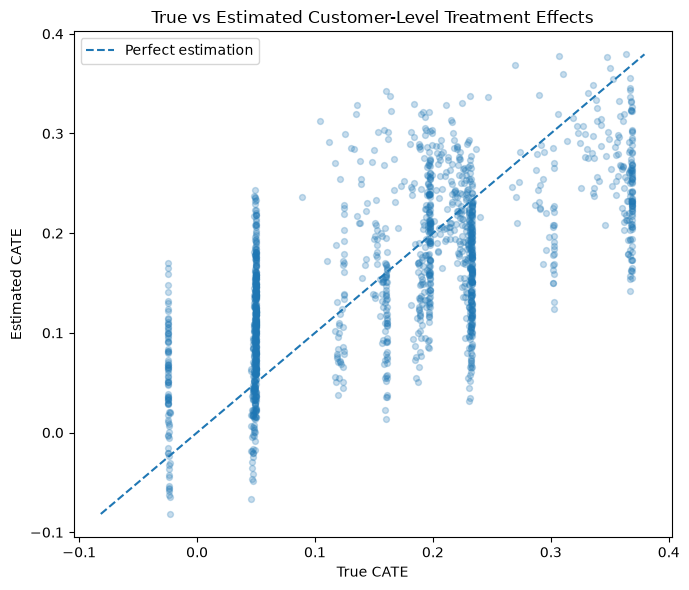

CATE figure saved to: D:\article28-unet-projects\predictive-vs-causal-decision-lab\reports\figures\true_vs_estimated_cate.png
CATE figure exists: True


In [11]:
import matplotlib.pyplot as plt


REPORTS_FIGURES_DIR = (
    PROJECT_ROOT
    / "reports"
    / "figures"
)

REPORTS_FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


cate_figure_path = (
    REPORTS_FIGURES_DIR
    / "true_vs_estimated_cate.png"
)


identity_min = min(
    true_cate_test.min(),
    cate_hat_test.min(),
)

identity_max = max(
    true_cate_test.max(),
    cate_hat_test.max(),
)


plt.figure(
    figsize=(7, 6)
)

plt.scatter(
    true_cate_test,
    cate_hat_test,
    alpha=0.25,
    s=18,
)

plt.plot(
    [identity_min, identity_max],
    [identity_min, identity_max],
    linestyle="--",
    label="Perfect estimation",
)

plt.xlabel(
    "True CATE"
)

plt.ylabel(
    "Estimated CATE"
)

plt.title(
    "True vs Estimated Customer-Level Treatment Effects"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    cate_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print(
    "CATE figure saved to:",
    cate_figure_path,
)

print(
    "CATE figure exists:",
    cate_figure_path.exists(),
)

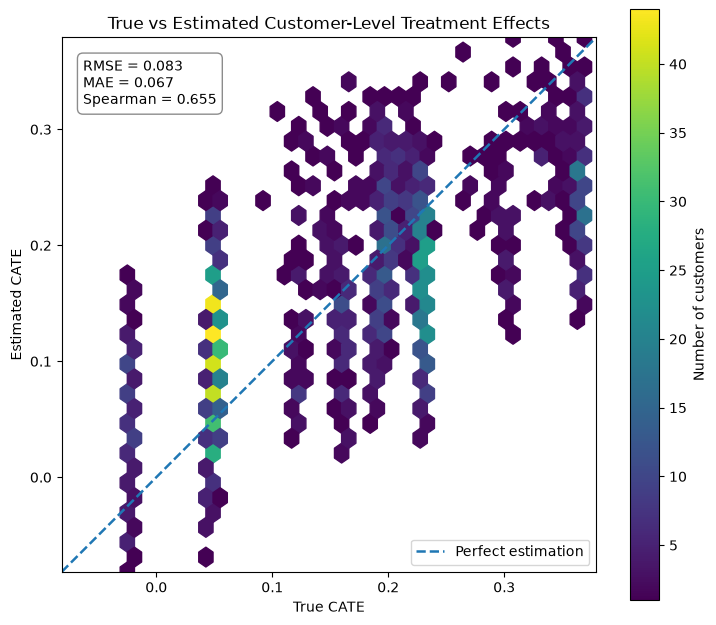

Improved CATE figure saved to: D:\article28-unet-projects\predictive-vs-causal-decision-lab\reports\figures\true_vs_estimated_cate_hexbin.png
Improved CATE figure exists: True


In [13]:
cate_hexbin_path = (
    REPORTS_FIGURES_DIR
    / "true_vs_estimated_cate_hexbin.png"
)


plot_min = min(
    true_cate_test.min(),
    cate_hat_test.min(),
)

plot_max = max(
    true_cate_test.max(),
    cate_hat_test.max(),
)


fig, ax = plt.subplots(
    figsize=(7.5, 6.5)
)


hexbin = ax.hexbin(
    true_cate_test,
    cate_hat_test,
    gridsize=32,
    mincnt=1,
)


ax.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
    linewidth=1.8,
    label="Perfect estimation",
)


ax.set_xlim(
    plot_min,
    plot_max,
)

ax.set_ylim(
    plot_min,
    plot_max,
)

ax.set_aspect(
    "equal",
    adjustable="box",
)


ax.set_xlabel(
    "True CATE"
)

ax.set_ylabel(
    "Estimated CATE"
)

ax.set_title(
    "True vs Estimated Customer-Level Treatment Effects"
)


metrics_text = (
    f"RMSE = {cate_rmse:.3f}\n"
    f"MAE = {cate_mae:.3f}\n"
    f"Spearman = {spearman_correlation:.3f}"
)


ax.text(
    0.04,
    0.96,
    metrics_text,
    transform=ax.transAxes,
    verticalalignment="top",
    fontsize=10,
    bbox={
        "boxstyle": "round,pad=0.4",
        "facecolor": "white",
        "edgecolor": "gray",
        "alpha": 0.9,
    },
)


ax.legend(
    loc="lower right"
)


colorbar = fig.colorbar(
    hexbin,
    ax=ax,
)

colorbar.set_label(
    "Number of customers"
)


fig.tight_layout()

fig.savefig(
    cate_hexbin_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print(
    "Improved CATE figure saved to:",
    cate_hexbin_path,
)

print(
    "Improved CATE figure exists:",
    cate_hexbin_path.exists(),
)

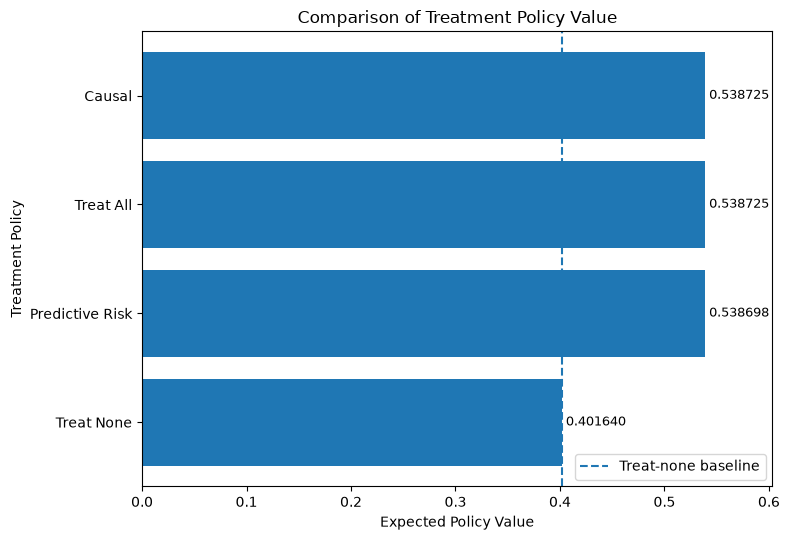

Policy figure saved to: D:\article28-unet-projects\predictive-vs-causal-decision-lab\reports\figures\policy_value_comparison.png
Policy figure exists: True


In [16]:
policy_figure_path = (
    REPORTS_FIGURES_DIR
    / "policy_value_comparison.png"
)


policy_plot_df = (
    policy_comparison
    .sort_values(
        "policy_value",
        ascending=True,
    )
    .copy()
)


fig, ax = plt.subplots(
    figsize=(8, 5.5)
)


bars = ax.barh(
    policy_plot_df["policy"],
    policy_plot_df["policy_value"],
)


ax.set_xlabel(
    "Expected Policy Value"
)

ax.set_ylabel(
    "Treatment Policy"
)

ax.set_title(
    "Comparison of Treatment Policy Value"
)


ax.set_xlim(
    0,
    policy_plot_df["policy_value"].max()
    * 1.12,
)


for bar, value in zip(
    bars,
    policy_plot_df["policy_value"],
):
    ax.text(
        value + 0.004,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.6f}",
        verticalalignment="center",
        fontsize=9,
    )


ax.axvline(
    treat_none_value,
    linestyle="--",
    linewidth=1.5,
    label="Treat-none baseline",
)


ax.legend(
    loc="lower right"
)

fig.tight_layout()


fig.savefig(
    policy_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print(
    "Policy figure saved to:",
    policy_figure_path,
)

print(
    "Policy figure exists:",
    policy_figure_path.exists(),
)